### Gráficos:  
  
Gráfico 1 - Correlação entre Produto Estadual e Produto Nacional (2000-2023)   
Gráfico 2 - Sincronia Fiscal: Correlação entre Receita Corrente Líquida (RCL) e Produto Nacional (2000-2023)  
Gráfico 3 - Evolução das Despesas Correntes e de Investimento (% do PIB)  
Gráfico 4 - Capacidade de Financiamento Total (CFT) versus hiato do produto estadual (2000-2023)  
Gráfico 5 - Evolução do Endividamento Subnacional (DCL/RCL): 2000-2023   
Gráfico 6 - Sustentabilidade: Razão da Dívida (DCL/RCL) vs. Hiato do produto  
  

Obs. os dados dos gráficos e tabelas segue a planilha em anexo com os dados. Servem para a análise descritiva

In [ ]:
# pacotes necessários

!pip install pandas numpy matplotlib seaborn geopandas statsmodels scipy scienceplots

#### Gráfico 1 - Correlação entre produto estadual e produto nacional (2000-2023)  
  
Descrição:  
  
Apresenta a relação entre o produto estadual e o produto nacional. O objetivo é desmontrar a elevada correlação entre os dois produtos. Assim, justificar que existe um movimento comum do produto nacional e dos estaduais ao longo dos ciclos econômicos. É coerente com a literatura sobre convergência que sugere uma não convegência ou muito lenta entre os estados. Dado que os estados tendem a crescer a taxas similares.


In [ ]:
# Gráfico 1 - Correlação entre produto estadual e produto nacional (2000-2023)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos Dados

df_gra01 = pd.read_excel('gratab_data.xlsx', sheet_name='gra01')

# Padronizar nomes de colunas

df_gra01.columns = [c.lower().strip() for c in df_gra01.columns]

# Remover colunas vazias

df_gra01 = df_gra01.loc[:, ~df_gra01.columns.str.contains('unnamed')]

# Converter ano em numérico

df_gra01['ano'] = pd.to_numeric(df_gra01['ano'], errors='coerce').astype(int)

# Mapeamento de Regiões
regioes_map = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# 2. Processamento do Painel e Cálculo de Variações

df_gra01 = df_gra01.set_index(['uf', 'ano']).sort_index()

# Calcular taxas de variação (%)

df_gra01['var_pib_est'] = df_gra01.groupby(level='uf')['pib_est_ipca'].pct_change() * 100
df_gra01['var_pib_nac'] = df_gra01.groupby(level='uf')['pib_nac_ipca'].pct_change() * 100

# Criar o df_plot (removendo os NaNs gerados pelo cálculo de variação do primeiro ano)

df_plot = df_gra01.reset_index().dropna(subset=['var_pib_est', 'var_pib_nac'])

# 3. Cálculo da correlação individual por UF

df_correlacao = df_plot.groupby('uf').apply(
    lambda x: x['var_pib_est'].corr(x['var_pib_nac'])
).reset_index()
df_correlacao.columns = ['uf', 'r_pearson']

# Adicionar a região para o gráfico

df_correlacao['regiao'] = df_correlacao['uf'].map(regioes_map)
df_correlacao = df_correlacao.sort_values('r_pearson', ascending=False)

# 4. Construção do Gráfico (Lollipop Chart)

plt.figure(figsize=(10, 8))

# Linhas horizontais (trilhos)

plt.hlines(y=df_correlacao['uf'], xmin=0, xmax=df_correlacao['r_pearson'], 
           color='lightgray', alpha=0.5, lw=1)

# Pontos (Pirulitos)

sns.scatterplot(data=df_correlacao, x='r_pearson', y='uf', hue='regiao', 
                s=120, palette='viridis', edgecolor='black', zorder=3)

# Linha da correlação média global (parâmetro 0.56)

plt.axvline(0.56, color='#e74c3c', linestyle='--', lw=2, label='Média Global (0.56)')

# Customização e Estética

plt.title('Gráfico 1 - Correlação entre Produto Estadual e Produto Nacional (2000-2023)', 
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel('Coeficiente de Correlação de Pearson (r)', fontsize=11)
plt.ylabel('Unidade Federativa', fontsize=11)
plt.legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.xlim(0, 1.05) 

# Nota explicativa alinhada à esquerda

nota_final = (f"Fonte: IBGE e elaborado pelo autor. \n"
              f"Nota: Cada ponto representa o coeficiente de correlação entre a taxa de crescimento do produto estadual e nacional.\n"
              f"A linha tracejada (0.56) indica a média de sincronia do federalismo brasileiro. Os estados foram organizados de \n"
              f"acordo com a correlação entre produto estadual e o produto nacional.")

plt.figtext(0.01, -0.05, nota_final, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

plt.figure(figsize=(7, 4))

plt.tight_layout()
plt.savefig('graf_01_final.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Gráfico 1 - Correlação entre produto estadual e produto nacional (2000-2023) - alternativo


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Preparação dos Dados
df_gra01 = pd.read_excel('gratab_data.xlsx', sheet_name='gra01')
df_gra01.columns = [c.lower().strip() for c in df_gra01.columns]
df_gra01 = df_gra01.loc[:, ~df_gra01.columns.str.contains('unnamed')]
df_gra01['ano'] = pd.to_numeric(df_gra01['ano'], errors='coerce').astype(int)

# Mapeamento de Regiões
regioes_map = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

df_gra01['regiao'] = df_gra01['uf'].map(regioes_map)

# Cálculo das variações no painel
df_gra01 = df_gra01.set_index(['uf', 'ano']).sort_index()
df_gra01['var_pib_est'] = df_gra01.groupby(level='uf')['pib_est_ipca'].pct_change() * 100
df_gra01['var_pib_nac'] = df_gra01.groupby(level='uf')['pib_nac_ipca'].pct_change() * 100

# Ordenar por Região e depois por UF para garantir o agrupamento visual
df_plot = df_gra01.reset_index().dropna(subset=['var_pib_est', 'var_pib_nac'])
df_plot = df_plot.sort_values(['regiao', 'uf'])

# 2. Funções de anotação individual (r por estado)
def annotate_corr(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.85), xycoords=ax.transAxes, 
                fontsize=10, fontweight='bold', color='darkred', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.7))

# 3. Criação do Painel Agrupado
# O parâmetro col_order garante que os estados apareçam agrupados por região
order_uf = df_plot['uf'].unique()
g = sns.FacetGrid(df_plot, col="uf", col_wrap=6, height=2.8, aspect=1.2, 
                  sharex=True, sharey=True, col_order=order_uf)

g.map(sns.regplot, "var_pib_nac", "var_pib_est", 
      scatter_kws={'alpha':0.5, 's':15, 'color':'#2980b9'}, 
      line_kws={'color':'#c0392b', 'lw':1.8})

g.map(annotate_corr, "var_pib_nac", "var_pib_est")

# Ajustes de Layout e Títulos
g.set_axis_labels("Brasil (%)", "Estado (%)")
g.set_titles("{col_name}", fontweight='bold', size=13)
g.fig.suptitle('Gráfico 1 - Correlação entre produto estadual e produto nacional (2000-2023)', 
               fontsize=18, fontweight='bold', y=1.05)

# Cálculo da correlação global para a nota
corr_global = df_plot['var_pib_est'].corr(df_plot['var_pib_nac'])

# NOTA EXPLICATIVA ALINHADA À ESQUERDA
nota = (f"Nota: O gráfico apresenta a correlação de Pearson (r) entre as taxas de variação real do PIB nacional e estadual.\n"
        f"A correlação global de {corr_global:.2f} indica uma forte sincronia cíclica no federalismo brasileiro.\n"
        f"Estados agrupados por proximidade regional apresentam padrões de resposta similares aos choques comuns do produto nacional.")

plt.figtext(0.01, -0.05, nota, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round", fc="#f8f9fa", ec="lightgray"), style='italic')

for ax in g.axes.flatten():
    ax.axhline(0, color='black', lw=0.5, ls='-', alpha=0.3)
    ax.axvline(0, color='black', lw=0.5, ls='-', alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('graf_01_alternativo.png', dpi=300, bbox_inches='tight')
plt.show()

#### Gráfico 2 - Sincronia Fiscal: Correlação entre Receita Corrente Líquida (RCL) e Produto Nacional  (2000-2023) 
  
Descrição:  
  
Explora a correlação entre a Receita Corrente Líquida (RCL) que inclui receita própria, transferências, ativos e passivos dos estados em relação ao produto estadual. O objetivo é explorar que a correlação é menor 

In [ ]:
# Gráfico 2 - Sincronia Fiscal: Correlação entre Receita Corrente Líquida (RCL) e Produto Nacional  (2000-2023)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo acadêmico
sns.set_theme(style="white") 
plt.rcParams.update({'font.size': 12})

# 1. Carregamento e Preparação
df_gra02 = pd.read_excel('gratab_data.xlsx', sheet_name='gra02')

# Cálculo da participação RCL/PIB_est por ano e depois a média por UF
df_gra02['participacao'] = df_gra02['rcl'] / df_gra02['pib_est']

# Agrupamento para métricas por UF
stats = df_gra02.groupby('uf').apply(lambda x: pd.Series({
    'correlation': x['pib_nac'].corr(x['rcl']),
    'mean_part': x['participacao'].mean()
})).reset_index()

stats = stats.sort_values(by='mean_part', ascending=False)

# 2. Construção do Gráfico com Eixo Duplo
fig, ax1 = plt.subplots(figsize=(14, 8))

# Eixo 1 (Esquerda): Barras para a Participação RCL/PIB_est
cor_bar = sns.color_palette("YlOrBr_r", n_colors=len(stats))
ax1.bar(stats['uf'], stats['mean_part'], color=cor_bar, label=r'Participação $RCL/PIB_{est}$')
ax1.set_xlabel('Unidade da Federação ($UF$)')
ax1.set_ylabel(r'Participação Média ($RCL/PIB_{est}$)', color='black')
ax1.tick_params(axis='y', labelcolor='black')


# Eixo 2 (Direita): Linha/Pontos para a Correlação de Pearson
ax2 = ax1.twinx()
# Importante: o plot segue a ordem do dataframe 'stats' que já está ordenado
ax2.plot(stats['uf'], stats['correlation'], color='navy', marker='o', linestyle='-', linewidth=2, label=r'Correlação ($\rho$)')
ax2.set_ylabel(r'Coeficiente de Correlação ($\rho$)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Limite do eixo Y para a correlação conforme solicitado
ax2.set_ylim(0.75, 1.00)

# Título e Legendas
plt.title(r'Gráfico 2 - Sincronia Fiscal: entre Receita Corrente Líquida (RCL) e o Produto Nacional (2000-2023)', 
fontsize=14, fontweight='bold', loc='left', pad=20)

# Consolidação das legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True)

# Texto da nota corrigido
texto_nota = (f"Fonte: IBGE e Secretaria do Tesouro Nacional (STN). Elaborado pelo autor.\n"
              f"Nota: A correlação de Pearson entre RCL e Produto Nacional aproxima-se de 1,0, o que evidencia elevada sincronia fiscal.\n"
              f"A linha navy tracejada indica a média da correlação. Os estados encontram-se organizados pela participação da RCL no produto estadual.\n"
              f"A sincronia da receita com o ciclo nacional supera a observada entre o produto estadual e o produto nacional.")


plt.figtext(0.01, -0.05, nota_final, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

# Ajuste o layout para que a nota não seja cortada
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

plt.savefig('correlacao_e_participacao_rcl_final.png', dpi=300, bbox_inches='tight')

### Gráfico 3 - Evolução das Despesas Correntes e de Investimento (% do PIB)  
  
Descrição:  
  
Explora a tamanho da despesa primária em relação ao RCL e a composição entre despesas correntes e o investimento


In [ ]:
# Gráfico 3 - Evolução das Despesas Correntes e de Investimento (% do PIB)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
try:
    df_gra03 = pd.read_excel('gratab_data.xlsx', sheet_name='gra03')
except FileNotFoundError:
    print("Erro: O arquivo 'gratab_data.xlsx' não foi encontrado.")

# Padronização
df_gra03.columns = [c.lower().strip() for c in df_gra03.columns]
df_gra03['ano'] = pd.to_numeric(df_gra03['ano'], errors='coerce')

# --- 2. PROCESSAMENTO ---
df_agg_raw = df_gra03.groupby('ano')[['desp_cap_invest', 'desp_cor', 'pib_est']].sum()
df_agg = pd.DataFrame(index=df_agg_raw.index)
df_agg['part_corrente'] = (df_agg_raw['desp_cor'] / df_agg_raw['pib_est']) * 100
df_agg['part_invest'] = (df_agg_raw['desp_cap_invest'] / df_agg_raw['pib_est']) * 100

# --- 3. CONFIGURAÇÃO DE ESTILO ---
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 11})

# --- 4. CONSTRUÇÃO DO GRÁFICO ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# Eixo 1: Despesa Corrente
ax1.plot(df_agg.index, df_agg['part_corrente'], color='#c0392b', lw=3, 
         label='Despesa Corrente (% do PIB)', marker='s', markersize=6)
ax1.set_ylabel('Despesa Corrente (% do PIB)', color='black', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# Eixo 2: Investimento
ax2 = ax1.twinx()
ax2.plot(df_agg.index, df_agg['part_invest'], color='#1f77b4', lw=2.5, 
         label='Investimento (% do PIB)', marker='o', markerfacecolor='white', markeredgewidth=2)
ax2.set_ylabel('Investimento (% do PIB)', color='black', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# --- 5. DELIMITAÇÃO DAS CRISES (RETAS VERTICAIS) ---
crises = {
    2008: "Crise de 2008",
    2015: "Crise Fiscal",
    2020: "COVID-19"
}

for ano, label in crises.items():
    if ano in df_agg.index:
        # Desenha a reta vertical
        ax1.axvline(x=ano, color='gray', linestyle='--', lw=1.5, alpha=0.7)
        # Adiciona o rótulo no topo da reta
        ax1.text(ano, ax1.get_ylim()[1] * 0.95, label, rotation=90, 
                 verticalalignment='top', horizontalalignment='right', 
                 fontsize=10, fontweight='bold', color='#555555')

# 6. Sombreamento de Fundo (Manter para contexto visual)
ax1.axvspan(2004, 2014, color='#e5f5e0', alpha=0.2) # Expansão
ax1.axvspan(2014, 2022, color='#fde0dd', alpha=0.2) # Período de Instabilidade

# 7. Anotações de Corte (Apenas nos anos de crise para clareza)
for ano in [2008, 2015, 2020]:
    if ano in df_agg.index:
        y_val = df_agg.loc[ano, 'part_invest']
        ax2.annotate('Corte', xy=(ano, y_val), xytext=(ano, y_val + 0.4),
                     arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1),
                     ha='center', fontsize=9, fontweight='bold')

# --- 8. FINALIZAÇÃO E NOTAS ---
plt.title('Gráfico 3 - Impacto de Crises na Composição da Despesa (% do PIB)', 
          fontsize=14, fontweight='bold', loc='left', pad=25)
ax1.grid(True, linestyle=':', alpha=0.3)

# Legenda unificada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

# Nota de rodapé com transFigure para evitar vácuo
nota = ("Fonte: Secretaria do Tesouro Nacional (STN) e Siconfi. Elaborado pelo autor.\n"
        "Nota: As linhas verticais delimitam choques macroeconómicos onde se observa a compressão\n"
        "do investimento para a manutenção da rigidez das despesas correntes.")

plt.figtext(0.01, -0.05, nota_final, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig('grafico_03_crises.png', dpi=300, bbox_inches='tight')
plt.show()

#### Gráfico 4 - Capacidade de Financiamento Total (CFT) versus hiato do produto estadual (2000-2023)

Descrição:  

Indica a reação da Capacidade de Financiamento Total (CFT) que é o resultado total entre receita total e despesa total em relação ao ciclo ciclo econômico mensurado pelo (hiato positivo e hiato negativo)


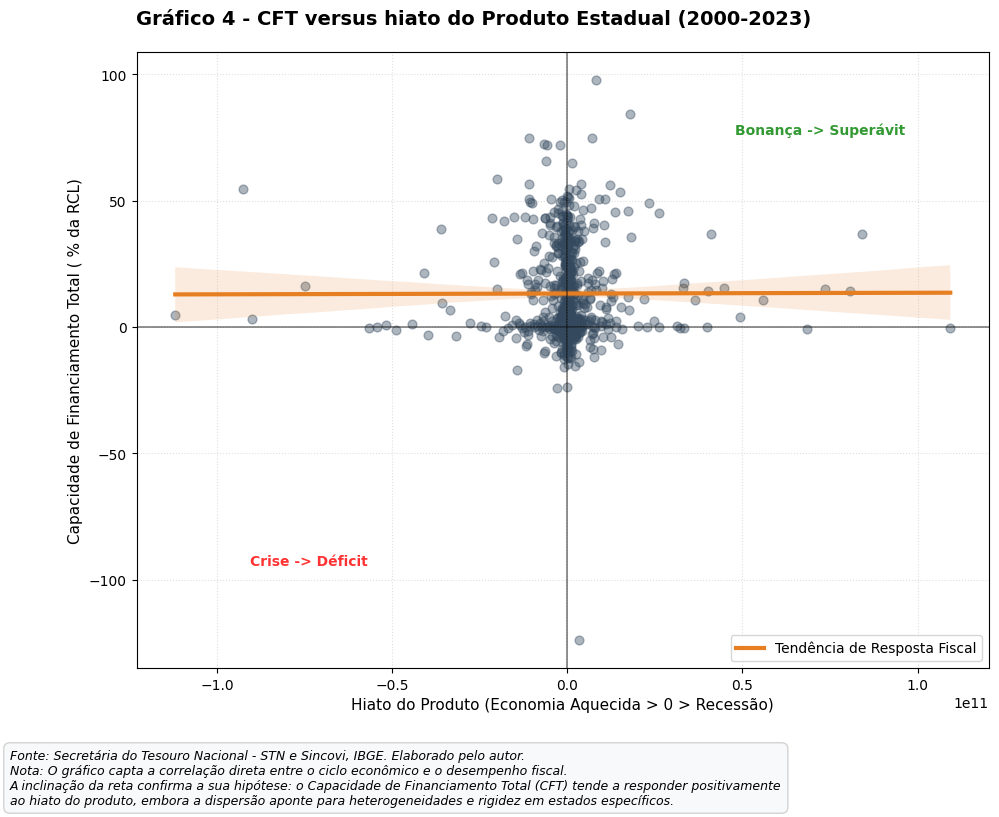

<Figure size 700x400 with 0 Axes>

In [3]:
# Gráfico 4 - Capacidade de Financiamento Total (CFT) versus hiato do produto estadual (2000-2023)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos Dados
try:
    df_gra04 = pd.read_excel('gratab_data.xlsx', sheet_name='gra04')
except:
    df_gra04 = pd.read_excel('gratab_data.xlsx', sheet_name='gra03')

# Padronizar nomes de colunas
df_gra04.columns = [c.lower().strip() for c in df_gra04.columns]
df_gra04['ano'] = pd.to_numeric(df_gra04['ano'], errors='coerce')

# 2. Construção do Gráfico (Foco na Sensibilidade de Resposta)
plt.figure(figsize=(11, 8))

# A Regressão Linear mostra exatamente a "taxa de resposta" do fiscal ao hiato.
# Se a linha for bem inclinada, o fiscal responde bem. Se for plana, há rigidez.
sns.regplot(data=df_gra04, x='pib_gap', y='cft_rcl', 
            scatter_kws={'alpha':0.4, 'color':'#34495e', 's':40}, 
            line_kws={'color':'#e67e22', 'lw':3, 'label': 'Tendência de Resposta Fiscal'})

# --- LINHAS DE QUADRANTE (A lógica do seu argumento) ---
plt.axhline(0, color='black', lw=1.2, alpha=0.5)
plt.axvline(0, color='black', lw=1.2, alpha=0.5)

# Títulos e Labels
plt.title('Gráfico 4 - CFT versus hiato do Produto Estadual (2000-2023)', 
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel('Hiato do Produto (Economia Aquecida > 0 > Recessão)', fontsize=11)
plt.ylabel('Capacidade de Financiamento Total ( % da RCL)', fontsize=11)

# Anotações para marcar a lógica esperada que você citou
plt.text(plt.gca().get_xlim()[1]*0.6, plt.gca().get_ylim()[1]*0.7, 'Bonança -> Superávit', 
         fontsize=10, color='green', fontweight='bold', alpha=0.8, ha='center')
plt.text(plt.gca().get_xlim()[0]*0.6, plt.gca().get_ylim()[0]*0.7, 'Crise -> Déficit', 
         fontsize=10, color='red', fontweight='bold', alpha=0.8, ha='center')

# Customização estética
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower right', frameon=True)

# Nota explicativa focada na Resposta Fiscal
nota_4 = ("Fonte: Secretária do Tesouro Nacional - STN e Sincovi, IBGE. Elaborado pelo autor. \n"
          "Nota: O gráfico capta a correlação direta entre o ciclo econômico e o desempenho fiscal.\n"
          "A inclinação da reta confirma a sua hipótese: o Capacidade de Financiamento Total (CFT) tende a responder positivamente\n"
          "ao hiato do produto, embora a dispersão aponte para heterogeneidades e rigidez em estados específicos.")

plt.figtext(0.01, -0.06, nota_4, ha="left", fontsize=9, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

plt.figure(figsize=(7, 4))
plt.tight_layout()
plt.savefig('graf_04_sensibilidade.png', dpi=300, bbox_inches='tight')
plt.show()

#### Gráfico 5 - Evolução do Endividamento Subnacional (DCL/RCL): 2000-2023  

Descrição:  

Demonstrar a evolução da relação DCL/RCL entre 2000 e 2023

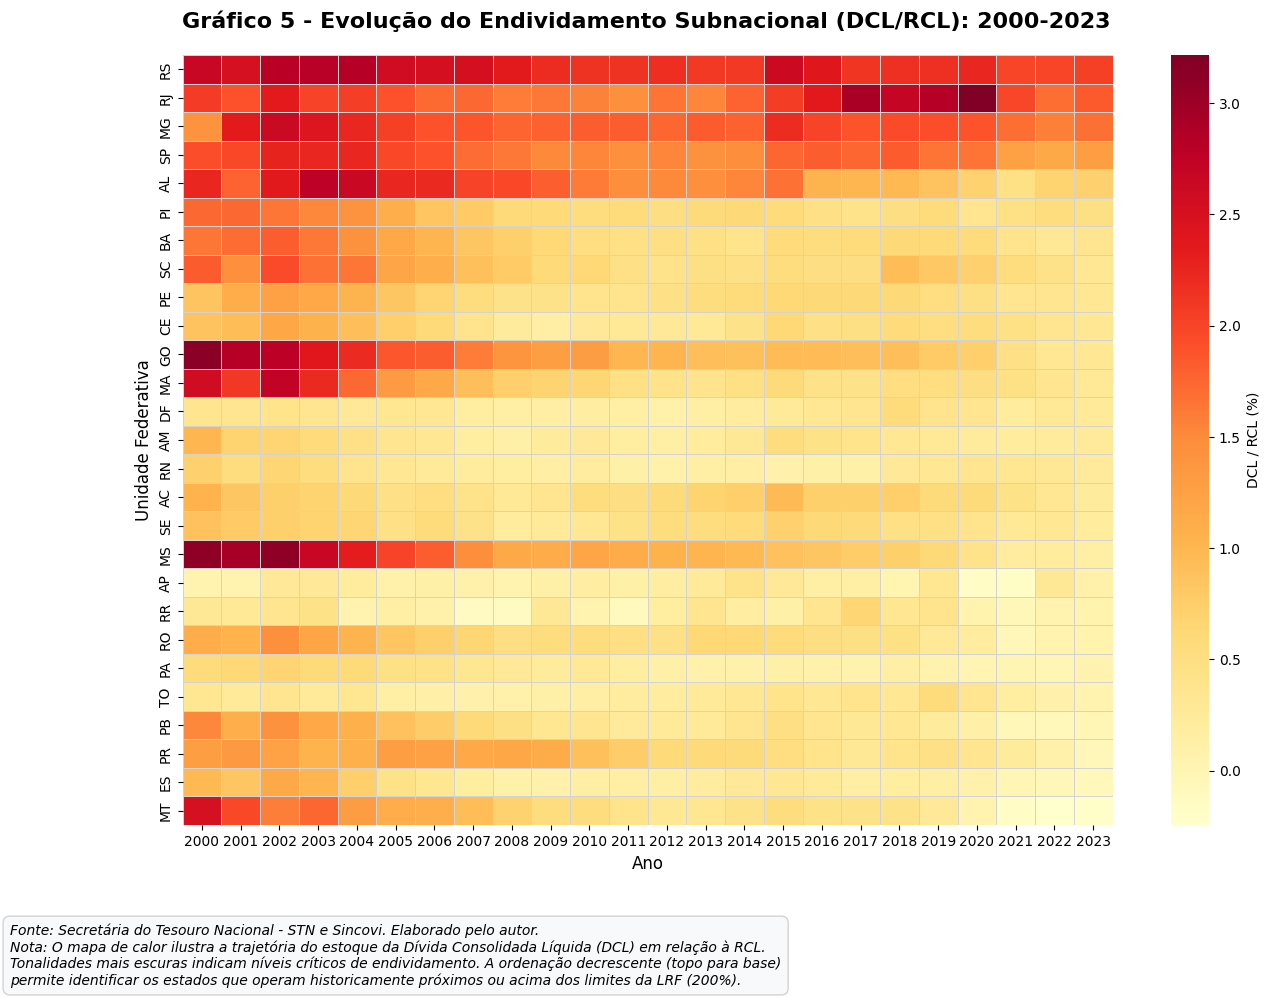

<Figure size 700x400 with 0 Axes>

In [1]:
# Gráfico 5 - Evolução do Endividamento Subnacional (DCL/RCL): 2000-2023

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos Dados
try:
    # A variável 'di_dcl' costuma estar em abas de endividamento
    df_gra05 = pd.read_excel('gratab_data.xlsx', sheet_name='gra05')
except:
    df_gra05 = pd.read_excel('gratab_data.xlsx', sheet_name='gra_01') # Ajuste conforme sua planilha

# Padronizar nomes de colunas
df_gra05.columns = [c.lower().strip() for c in df_gra05.columns]
df_gra05['ano'] = pd.to_numeric(df_gra05['ano'], errors='coerce')

# 2. Preparação para o Mapa de Calor
# Criar uma tabela dinâmica: Linhas (Estados), Colunas (Anos), Valores (DCL/RCL)
df_pivot = df_gra05.pivot(index='uf', columns='ano', values='di_dcl')

# Ordenar os estados pelo valor mais recente (2023) 
# Isso empurra os estados mais críticos (como RS, MG, RJ, SP) para o topo
df_pivot = df_pivot.sort_values(by=df_pivot.columns[-1], ascending=False)

# 3. Construção do Gráfico
plt.figure(figsize=(15, 10))

# Criar o heatmap usando a paleta 'YlOrRd' (Amarelo -> Vermelho)
sns.heatmap(df_pivot, annot=False, cmap='YlOrRd', cbar_kws={'label': 'DCL / RCL (%)'},
            linewidths=.5, linecolor='lightgray')

# Customização Acadêmica
plt.title('Gráfico 5 - Evolução do Endividamento Subnacional (DCL/RCL): 2000-2023', 
          fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Unidade Federativa', fontsize=12)

# Nota explicativa alinhada à esquerda
nota_5 = ("Fonte: Secretária do Tesouro Nacional - STN e Sincovi. Elaborado pelo autor. \n"
          "Nota: O mapa de calor ilustra a trajetória do estoque da Dívida Consolidada Líquida (DCL) em relação à RCL.\n"
          "Tonalidades mais escuras indicam níveis críticos de endividamento. A ordenação decrescente (topo para base)\n"
          "permite identificar os estados que operam historicamente próximos ou acima dos limites da LRF (200%).")

plt.figtext(0.01, -0.05, nota_5, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

plt.figure(figsize=(7, 4))
plt.tight_layout()
plt.savefig('graf_05_heatmap_divida.png', dpi=300, bbox_inches='tight')
plt.show()

#### Gráfico 6 - Sustentabilidade: Razão da Dívida (DCL/RCL) vs. Hiato do produto   

Descrição:  

Cruzamos informações da relação DCL/RCL e o hiato do produto

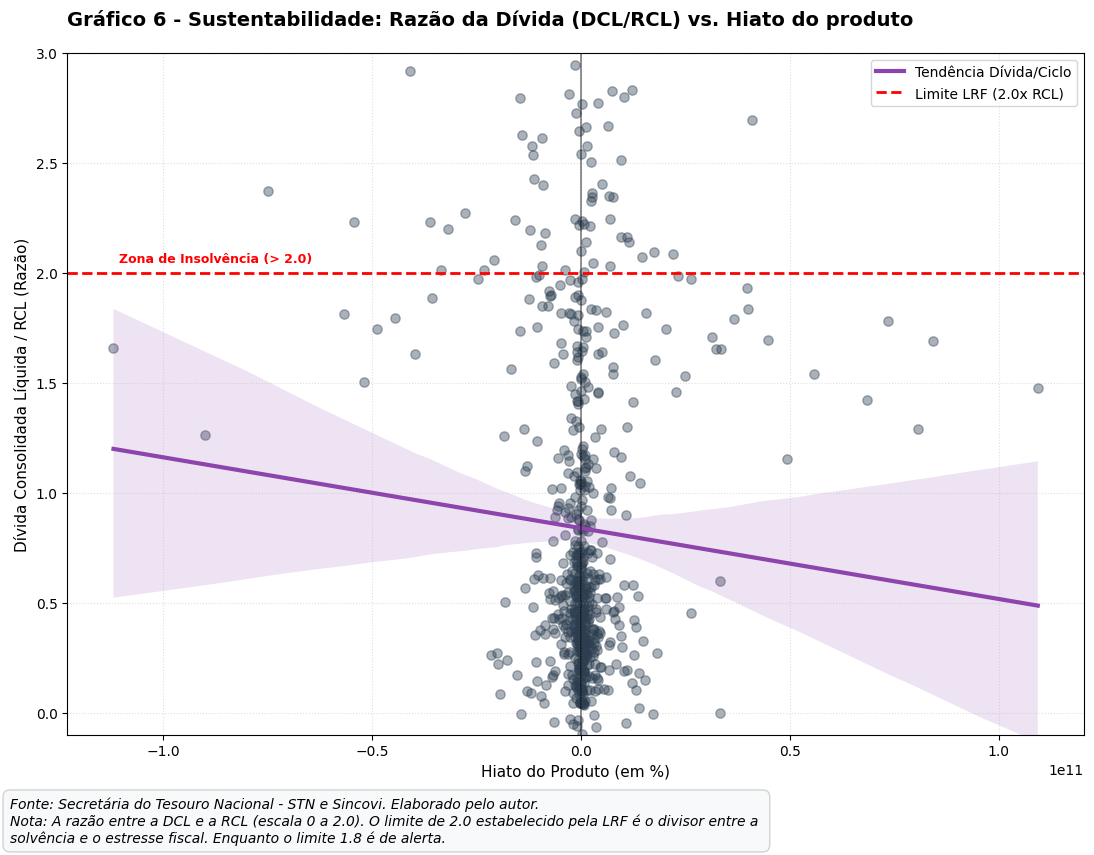

In [3]:
# Gráfico 6 - Sustentabilidade: Razão da Dívida (DCL/RCL) vs. Hiato do produto


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos Dados

df_gra06 = pd.read_excel('gratab_data.xlsx', sheet_name='gra06')

df_gra06.columns = [c.lower().strip() for c in df_gra06.columns]

# 2. Construção do Gráfico (Ajustado para Escala Decimal 0 - 2.0)
plt.figure(figsize=(11, 8))

# X = pib_gap (Hiato), Y = di_dcl (DCL/RCL em decimais)
sns.regplot(data=df_gra06, x='pib_gap', y='di_dcl', 
            scatter_kws={'alpha':0.4, 'color':'#2c3e50', 's':45}, 
            line_kws={'color':'#8e44ad', 'lw':3, 'label': 'Tendência Dívida/Ciclo'})

# --- MARCOS LEGAIS (Ajustado para 2.0) ---
plt.axvline(0, color='black', lw=1.2, alpha=0.5) # Linha do Hiato Zero
plt.axhline(2.0, color='red', linestyle='--', lw=2, label='Limite LRF (2.0x RCL)') 

# Títulos e Labels
plt.title('Gráfico 6 - Sustentabilidade: Razão da Dívida (DCL/RCL) vs. Hiato do produto', 
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel('Hiato do Produto (em %)', fontsize=11)
plt.ylabel('Dívida Consolidada Líquida / RCL (Razão)', fontsize=11)

# Ajuste do limite do eixo Y para focar na zona crítica (0 a 2.5)
# Isso evita que estados com dívidas astronômicas esmaguem a visualização
plt.ylim(-0.1, 3.0) 

# Anotações para interpretação
plt.text(plt.gca().get_xlim()[0]*0.9, 2.05, 'Zona de Insolvência (> 2.0)', 
         color='red', fontsize=9, fontweight='bold')

# Customização estética
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True)

# Nota explicativa
nota_6 = ("Fonte: Secretária do Tesouro Nacional - STN e Sincovi. Elaborado pelo autor.\n" 
          "Nota: A razão entre a DCL e a RCL (escala 0 a 2.0). O limite de 2.0 estabelecido pela LRF é o divisor entre a \n" 
          "solvência e o estresse fiscal. Enquanto o limite 1.8 é de alerta.")

plt.figtext(0.01, -0.06, nota_6, ha="left", fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="lightgray"), style='italic')

plt.tight_layout()
plt.savefig('graf_06_divida_decimal.png', dpi=300, bbox_inches='tight')
plt.show()

## FIM